# 03. cuPF CPU path: KLU, UMFPACK, fixed Jacobian pattern

cuPF CPU는 GPU 없이도 비교 기준이 됩니다. 여기서는 세 가지를 분리해서 봅니다.

1. pandapower-like Jacobian + UMFPACK: SciPy/pandapower와 가까운 비교 경로
2. pandapower-like Jacobian + KLU: 선형 solver만 KLU로 바꾼 경로
3. native fixed-pattern Jacobian + KLU: cuPF의 기본 CPU 최적화 경로

핵심은 Newton iteration마다 Jacobian 값은 바뀌지만 **sparse pattern은 거의 고정**이라는 점입니다. cuPF는 이 구조를 재사용해 symbolic analysis와 sparse assembly 비용을 줄입니다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_LIVE = True


In [2]:
case = tu.load_case(TUTORIAL_CASE)
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}")
print('Building CPU evaluation artifacts...')
build = tu.build_eval('cpu', jobs=2, timeout=2400)
print(tu.command_summary(build))


case=case6468rte, buses=6468, ybus_nnz=22598
Building CPU evaluation artifacts...


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.3s
[build_eval] configure (cpu) -> /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
-- spdlog not found: disabling cuPF logging
-- Found pybind11: /usr/local/include (found version "3.0.1")
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cp

$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-cpu-20260601-103923 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-cpu-umfpack-pandapower-jac-pybind cupf-cpu-klu-pandapower-jac-pybind cupf-cpu-klu-pybind
[OK] elapsed=11.2s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-cpu-20260601-103923 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-pandapower-jac-pybind cupf-cpu-klu-pybind cupf-cpu-umfpack-pandapower-jac-pybind
[cupf-cpu-klu-pybind][OK] case6468rte repeat=0 init_ms=7.806 solve_ms=12.141 iters=4 resid=1.341e-11
[cupf-cpu-klu-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-cpu-20260601-103923/cupf-cpu-

,variant,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual
0,cupf-cpu-klu-pandapower-jac-pybind,klu,pandapower,7.806547,12.093080,1.340572e-11
1,cupf-cpu-klu-pybind,klu,native,7.806387,12.141240,1.340572e-11
2,cupf-cpu-umfpack-pandapower-jac-pybind,umfpack,pandapower,9.329712,57.804931,1.015891e-11


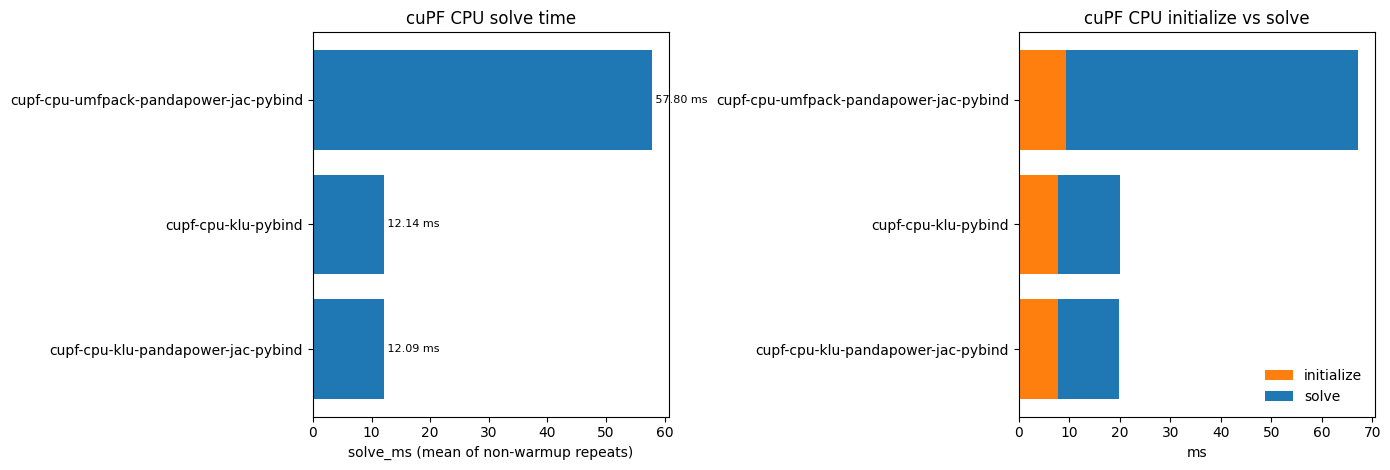

In [3]:
variants = [
    'cupf-cpu-umfpack-pandapower-jac-pybind',
    'cupf-cpu-klu-pandapower-jac-pybind',
    'cupf-cpu-klu-pybind',
]
if RUN_LIVE and build.ok:
    run_dir, result = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-cpu'),
        cases=[TUTORIAL_CASE],
        repeats=1,
        warmup=0,
        timeout=3600,
    )
    print(tu.command_summary(result))
else:
    run_dir = tu.tutorial_output_root()
    print('CPU benchmark skipped because build failed or RUN_LIVE=False')

print(f"run_dir={run_dir}")
runs = tu.load_tutorial_runs(run_dir)
summary = tu.summarize_runs(runs)
display(summary[['variant', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual']])
skipped = tu.skipped_variants(run_dir)
if not skipped.empty:
    display(skipped)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
tu.plot_run_solve_bars(summary, axes[0], 'cuPF CPU solve time')
tu.plot_init_solve_stack(summary, axes[1], 'cuPF CPU initialize vs solve')
plt.tight_layout()


UMFPACK은 pandapower/SciPy가 `use_umfpack=True`일 때 기대하는 SuiteSparse 계열과 개념적으로 가까운 비교점입니다. KLU는 전력계통처럼 회로형 sparse matrix에 강한 solver라 CPU baseline 개선 폭을 보여주는 데 적합합니다. `native` Jacobian은 pandapower 수식을 버린 것이 아니라, 같은 Newton 방정식을 cuPF 내부 sparse layout에 맞춰 더 직접적으로 채우는 경로입니다.
